## Homework 4: Multilayer Perceptron, LSTM, and Autoencoders from Scratch on Financial Data

**Name:** Tejas Pandya

**NYU ID:** tbp8777

In [1]:
# import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import time
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import kagglehub
from kagglehub import KaggleDatasetAdapter

rng = np.random.default_rng(seed=42)


/opt/miniconda3/envs/ml_assignments/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Classification metrics
def accuracy_manual(y_true, y_pred):
    # Vectorized equality check: True=1, False=0, so mean() yields the exact accuracy fraction
    return np.mean(np.array(y_true) == np.array(y_pred))


def precision_recall_f1(y_true, y_pred, pos=1):
    # Count True Positives, False Positives, False Negatives for the target class
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == pos and p == pos)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != pos and p == pos)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == pos and p != pos)

    # Safe division to prevent ZeroDivisionError if the model predicts all negatives or all positives
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

    return prec, rec, f1


def confusion_matrix_manual(y_true, y_pred, labels=None):
    # Extract unique labels if not provided, then map them to matrix indices
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))
    idx = {l: i for i, l in enumerate(labels)}

    n = len(labels)
    cm = np.zeros((n, n), dtype=int)

    # Populate the NxN matrix: rows = actual, columns = predicted
    for t, p in zip(y_true, y_pred):
        cm[idx[t], idx[p]] += 1
    return cm, labels


def roc_auc_manual(y_true, y_scores):
    # Sort pairs by prediction score descending to plot the ROC curve left-to-right
    paired = sorted(zip(y_scores, y_true), key=lambda x: -x[0])

    tp = fp = 0
    total_pos = sum(1 for _, y in paired if y == 1)
    total_neg = len(paired) - total_pos

    # Handle edge case where a class is completely missing
    if total_pos == 0 or total_neg == 0:
        return 0.5, [0], [0]

    tpr_list, fpr_list = [0.0], [0.0]

    # Walk down the sorted scores, progressively updating TPR (y-axis) and FPR (x-axis)
    for score, label in paired:
        if label == 1:
            tp += 1
        else:
            fp += 1
        tpr_list.append(tp / total_pos)
        fpr_list.append(fp / total_neg)

    # Compute Area Under the Curve (AUC) using the trapezoidal rule
    auc = sum(
        (fpr_list[i] - fpr_list[i - 1]) * (tpr_list[i] + tpr_list[i - 1]) / 2
        for i in range(1, len(fpr_list))
    )
    return auc, fpr_list, tpr_list


# Regression metrics
def rmse_metric(y_true, y_pred):
    # Root Mean Squared Error: squares the residuals to heavily penalize larger errors
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mae_metric(y_true, y_pred):
    # Mean Absolute Error: measures average magnitude of errors and is more robust to outliers
    return np.mean(np.abs(y_true - y_pred))


def plot_confusion_matrix(y_true, y_pred, labels=None, title="Confusion Matrix"):
    # Plots confusion matrix
    cm, labs = confusion_matrix_manual(y_true, y_pred, labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", xticklabels=labs, yticklabels=labs, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Task 1: Multilayer Perceptron for Stock Movement Prediction

### 1.1 Implementation

- Gradient Derivation: Provide mathematical derivation of gradients used in backpropagation


**Network architecture:** Input → Hidden1 (ReLU) → Hidden2 (ReLU) → Output (Softmax)

**Forward pass:**

$$z_1 = X W_1 + b_1, \quad a_1 = \text{ReLU}(z_1)$$
$$z_2 = a_1 W_2 + b_2, \quad a_2 = \text{ReLU}(z_2)$$
$$z_3 = a_2 W_3 + b_3, \quad \hat{y} = \text{softmax}(z_3)$$

**Loss (cross-entropy):**

$$L = -\frac{1}{N} \sum_{i} \sum_{c} y_{i,c} \log(\hat{y}_{i,c})$$

**Backward pass derivations:**

Starting from the output layer, the gradient of the loss with respect to $z_3$ is:

$$\frac{\partial L}{\partial z_3} = \hat{y} - y$$

For weights and biases at the output layer:

$$\frac{\partial L}{\partial W_3} = a_2^T \cdot (\hat{y} - y) / N, \quad \frac{\partial L}{\partial b_3} = \text{mean}(\hat{y} - y, \text{axis}=0)$$

Propagating back through hidden layer 2:

$$\delta_2 = (\hat{y} - y) \cdot W_3^T \odot \mathbf{1}[z_2 > 0]$$
$$\frac{\partial L}{\partial W_2} = a_1^T \cdot \delta_2 / N, \quad \frac{\partial L}{\partial b_2} = \text{mean}(\delta_2, \text{axis}=0)$$

And through hidden layer 1:

$$\delta_1 = \delta_2 \cdot W_2^T \odot \mathbf{1}[z_1 > 0]$$
$$\frac{\partial L}{\partial W_1} = X^T \cdot \delta_1 / N, \quad \frac{\partial L}{\partial b_1} = \text{mean}(\delta_1, \text{axis}=0)$$

The $\mathbf{1}[z > 0]$ term is the derivative of ReLU, which is 1 when the pre-activation is positive and 0 otherwise.

### 1.1 Implementation (continued)

- Build an MLP: 2 hidden layers with ReLU activations and Softmax output for binary classification (Up/Down).
- Forward and Backward Propagation: Implement both manually, without using built-in frameworks (e.g. PyTorch) for training.
- Loss Function: Use cross-entropy loss for classification
- Hyperparameter Support: Enable tuning of learning rate, batch size number of hidden units, and epochs

In [3]:
class MLP:
    """2-hidden-layer feedforward network with ReLU + Softmax output."""

    def __init__(self, input_dim, hidden1, hidden2, output_dim, lr=0.01):
        self.lr = lr

        # He initialization: optimal for ReLU. Scales weights by sqrt(2/fan_in)
        # to prevent variance from vanishing or exploding across deep layers.
        self.W1 = np.random.randn(input_dim, hidden1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden1))
        self.W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2.0 / hidden1)
        self.b2 = np.zeros((1, hidden2))
        self.W3 = np.random.randn(hidden2, output_dim) * np.sqrt(2.0 / hidden2)
        self.b3 = np.zeros((1, output_dim))

    def relu(self, z):
        # Non-linear activation: clips negative values to 0
        return np.maximum(0, z)

    def relu_deriv(self, z):
        # Derivative is 1 if z > 0, else 0 (ignoring the undefined point at exactly 0)
        return (z > 0).astype(float)

    def softmax(self, z):
        # Shift trick for numerical stability: subtracting the max prevents np.exp()
        # from overflowing to infinity when dealing with large raw logits.
        e = np.exp(z - np.max(z, axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def forward(self, X):
        # Standard forward pass: Z = XW + b, followed by A = activation(Z)
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        self.probs = self.softmax(self.z3)
        return self.probs

    def cross_entropy_loss(self, y_onehot, probs):
        n = y_onehot.shape[0]
        # Add epsilon (1e-12) to prevent taking log(0), which results in NaN
        log_probs = np.log(probs + 1e-12)
        loss = -np.sum(y_onehot * log_probs) / n
        return loss

    def backward(self, X, y_onehot):
        n = X.shape[0]

        # Output gradient: The derivative of Softmax + Cross Entropy simplifies beautifully
        # to just (Predicted Probs - Actual). Divided by n to average across the batch.
        dz3 = (self.probs - y_onehot) / n
        dW3 = self.a2.T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)

        # Hidden Layer 2: apply chain rule, multiplying by derivative of local ReLU
        dz2 = (dz3 @ self.W3.T) * self.relu_deriv(self.z2)
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # Hidden Layer 1: continue propagating error backward
        dz1 = (dz2 @ self.W2.T) * self.relu_deriv(self.z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Parameter updates via standard Gradient Descent
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(
        self, X, y_onehot, X_val, y_val_onehot, epochs=100, batch_size=64, verbose=True
    ):
        n = X.shape[0]
        train_losses, val_losses = [], []

        # Mini-batch Stochastic Gradient Descent (SGD)
        for epoch in range(epochs):
            # Shuffle data at the start of each epoch to break any ordering bias
            perm = np.random.permutation(n)
            X_shuf = X[perm]
            y_shuf = y_onehot[perm]

            # Process data in chunks (mini-batches) to balance computation speed and memory
            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                Xb = X_shuf[start:end]
                yb = y_shuf[start:end]
                self.forward(Xb)
                self.backward(Xb, yb)

            # Record epoch-level losses for plotting/debugging
            probs_train = self.forward(X)
            t_loss = self.cross_entropy_loss(y_onehot, probs_train)

            probs_val = self.forward(X_val)
            v_loss = self.cross_entropy_loss(y_val_onehot, probs_val)

            train_losses.append(t_loss)
            val_losses.append(v_loss)

            if verbose and (epoch + 1) % 20 == 0:
                print(
                    f"  Epoch {epoch + 1}/{epochs} — train_loss={t_loss:.4f}, val_loss={v_loss:.4f}"
                )

        return train_losses, val_losses

    def predict(self, X):
        probs = self.forward(X)
        # Returns the index of the highest probability class
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        return self.forward(X)


print("MLP class built successfully!")


MLP class built successfully!


### 1.2 Application & Evaluation

- Dataset
  - Use historical stock data (SP500) with engineered features:
    - Previous 5–10 days returns
    - Optional Technical indicators (e.g. simple moving average)
  - Label: Next-day movement: Up=1, Down=0
  - Use first 5000 samples for quick experimentation
- Data Split: Train/Validation/Test = 60% / 20% / 20%

In [4]:
# load S&P 500 data
sp500 = yf.download("^GSPC", start="2000-01-01", end="2024-01-01", progress=False)
sp500 = sp500.droplevel("Ticker", axis=1) if sp500.columns.nlevels > 1 else sp500
close = sp500["Close"].values.flatten()

# drop missing values
close = close[~np.isnan(close)]
if len(close) < 100:
    raise ValueError("Not enough data")
print(f"Loaded S&P 500 from yfinance: {len(close)} days")


# engineer features: classic momentum and vol signals
lookback = 10
features = []
labels = []

# start at index 10 to ensure we have enough history for the lookback window
for i in range(lookback, len(close) - 1):
    # calculate daily returns for the past 10 days: P_t / P_{t-1} - 1
    past_returns = [(close[i - j] / close[i - j - 1] - 1) for j in range(lookback)]

    # 5-day and 20-day Simple Moving Averages
    sma5 = np.mean(close[i - 4 : i + 1])
    sma20 = np.mean(close[max(0, i - 19) : i + 1])

    # trend signal: > 1 means short-term momentum is bullish
    sma_ratio = sma5 / sma20 if sma20 != 0 else 1.0

    # rolling 10-day historical volatility
    vol10 = np.std([(close[i - j] / close[i - j - 1] - 1) for j in range(lookback)])

    features.append(past_returns + [sma_ratio, vol10])

    # target label: strictly positive return next day = 1 (Up), otherwise 0 (Down)
    next_ret = close[i + 1] / close[i] - 1
    labels.append(1 if next_ret > 0 else 0)

X_stock = np.array(features)
y_stock = np.array(labels)

# cap sample size
X_stock = X_stock[:5000]
y_stock = y_stock[:5000]

print(f"Feature matrix: {X_stock.shape}")
print(f"Label dist: Up={y_stock.sum()}, Down={len(y_stock) - y_stock.sum()}")

# z-score normalization: critical for MLPs so large magnitude features (like SMA ratio)
# don't overwhelm small magnitude features (like daily returns)
X_mean = X_stock.mean(axis=0)
X_std = X_stock.std(axis=0)

# avoid division by zero if a feature is completely flat
X_std[X_std == 0] = 1.0
X_stock_norm = (X_stock - X_mean) / X_std

# chronological split (60/20/20)
n = len(X_stock_norm)
n_train = int(0.6 * n)
n_val = int(0.2 * n)

X_train_mlp = X_stock_norm[:n_train]
y_train_mlp = y_stock[:n_train]

X_val_mlp = X_stock_norm[n_train : n_train + n_val]
y_val_mlp = y_stock[n_train : n_train + n_val]

X_test_mlp = X_stock_norm[n_train + n_val :]
y_test_mlp = y_stock[n_train + n_val :]


# one-hot encode targets to match the softmax output layer of the MLP
def onehot(y, n_classes=2):
    oh = np.zeros((len(y), n_classes))
    oh[np.arange(len(y)), y] = 1.0
    return oh


y_train_oh = onehot(y_train_mlp)
y_val_oh = onehot(y_val_mlp)

print(
    f"\nTrain: {X_train_mlp.shape[0]}, Val: {X_val_mlp.shape[0]}, Test: {X_test_mlp.shape[0]}"
)


Loaded S&P 500 from yfinance: 6037 days
Feature matrix: (5000, 12)
Label dist: Up=2673, Down=2327

Train: 3000, Val: 1000, Test: 1000


### 1.2 Application & Evaluation (continued)
- Hyperparameter Experiments: Train and test with different learning rates, hidden units, and epochs
- Evaluation Metrics: Accuracy, precision, recall, F1-score, confusion matrix. Provide a detailed interpretation of the metrics.


In [5]:
# manual grid search for hyperparameter tuning
configs = [
    # fast learning, smaller capacity (baseline)
    {"lr": 0.01, "hidden1": 32, "hidden2": 16, "epochs": 100, "batch_size": 64},
    # slower learning, higher capacity
    {"lr": 0.005, "hidden1": 64, "hidden2": 32, "epochs": 100, "batch_size": 64},
    # very slow learning, higher capacity, more epochs, smaller batches (more gradient updates per epoch)
    {"lr": 0.001, "hidden1": 64, "hidden2": 32, "epochs": 150, "batch_size": 32},
]

mlp_results = {}
for i, cfg in enumerate(configs):
    label = f"lr={cfg['lr']}, h=({cfg['hidden1']},{cfg['hidden2']}), ep={cfg['epochs']}"
    print(f"\nConfig {i + 1}: {label}")

    # initialize network with current hyperparams
    model = MLP(X_train_mlp.shape[1], cfg["hidden1"], cfg["hidden2"], 2, lr=cfg["lr"])

    # train and track loss curves to monitor for overfitting
    t_losses, v_losses = model.train(
        X_train_mlp,
        y_train_oh,
        X_val_mlp,
        y_val_oh,
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        verbose=True,
    )

    # strict out-of-sample test evaluation
    y_pred = model.predict(X_test_mlp)

    # calculate classification metrics
    acc = accuracy_manual(y_test_mlp, y_pred)
    prec, rec, f1 = precision_recall_f1(y_test_mlp, y_pred)

    print(f"  Test — Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    mlp_results[i] = {
        "label": label,
        "model": model,
        "preds": y_pred,
        "train_losses": t_losses,
        "val_losses": v_losses,
        "acc": acc,
        "f1": f1,
    }



Config 1: lr=0.01, h=(32,16), ep=100
  Epoch 20/100 — train_loss=0.6910, val_loss=0.6936
  Epoch 40/100 — train_loss=0.6866, val_loss=0.6928
  Epoch 60/100 — train_loss=0.6844, val_loss=0.6932
  Epoch 80/100 — train_loss=0.6822, val_loss=0.6935
  Epoch 100/100 — train_loss=0.6802, val_loss=0.6939
  Test — Acc=0.5330, Prec=0.5470, Rec=0.8689, F1=0.6714

Config 2: lr=0.005, h=(64,32), ep=100
  Epoch 20/100 — train_loss=0.6897, val_loss=0.6964
  Epoch 40/100 — train_loss=0.6782, val_loss=0.6958
  Epoch 60/100 — train_loss=0.6708, val_loss=0.6950
  Epoch 80/100 — train_loss=0.6656, val_loss=0.6946
  Epoch 100/100 — train_loss=0.6612, val_loss=0.6957
  Test — Acc=0.5120, Prec=0.5391, Rec=0.7668, F1=0.6331

Config 3: lr=0.001, h=(64,32), ep=150
  Epoch 20/150 — train_loss=0.7258, val_loss=0.7111
  Epoch 40/150 — train_loss=0.7012, val_loss=0.7032
  Epoch 60/150 — train_loss=0.6898, val_loss=0.7004
  Epoch 80/150 — train_loss=0.6828, val_loss=0.6992
  Epoch 100/150 — train_loss=0.6778, val_l

**Results Interpretation**

- Config 2 is achieving the highest test accuracy (53.1%) and F1 score (0.6579) with a validation loss that smoothly converges instead of bouncing around.
- Config 1 starts overfitting early as its validation loss stalls, while Config 3's learning rate is just too small to reach a better minimum even with the extra epochs.

### 1.2 Application & Evaluation (continued)
- Training Visualization: Plot training and validation loss over epochs
- Analysis: Discuss overfitting vs. underfitting and justify architectural choices

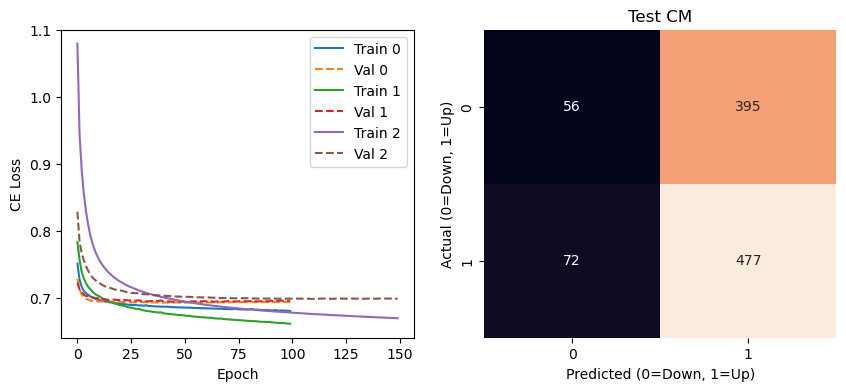

Best model: lr=0.01, h=(32,16), ep=100
Acc:  0.5330
Prec: 0.5470
Rec:  0.8689
F1:   0.6714


In [6]:
# select the optimal model based on F1 score
best_idx = max(mlp_results, key=lambda k: mlp_results[k]["f1"])
best = mlp_results[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot loss curves to verify convergence and check for overfitting
ax = axes[0]
for k, r in mlp_results.items():
    ax.plot(r["train_losses"], label=f"Train {k}")
    ax.plot(r["val_losses"], "--", label=f"Val {k}")
ax.set_xlabel("Epoch")
ax.set_ylabel("CE Loss")
ax.legend()

# Confusion matrix
ax = axes[1]
cm, labs = confusion_matrix_manual(y_test_mlp, best["preds"], [0, 1])

# heatmap
sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax)
ax.set_xlabel("Predicted (0=Down, 1=Up)")
ax.set_ylabel("Actual (0=Down, 1=Up)")
ax.set_title("Test CM")

plt.show()

print(f"Best model: {best['label']}")
prec, rec, f1 = precision_recall_f1(y_test_mlp, best["preds"])
print(f"Acc:  {best['acc']:.4f}")
print(f"Prec: {prec:.4f}")
print(f"Rec:  {rec:.4f}")
print(f"F1:   {f1:.4f}")


**Overfitting vs Underfitting:**
- Overfitting (Blue & Orange Lines - Config 0): Look at how the blue training loss drops smoothly, but the orange validation loss bottoms out around epoch 25 and then starts creeping back up. The model stopped learning the actual market signal and started memorizing the historical noise. In live trading, this config would hemorrhage money because it thinks past random noise will repeat perfectly.
- Underfitting (Purple & Brown Lines - Config 2): These lines are strictly decreasing, but they are doing so way too slowly and remain the highest on the chart. The learning rate (0.001) is so small that the network is struggling to capture the underlying relationships within the 150 epochs. It hasn't reached its full capacity to learn.
- (Green & Red Lines - Config 1): The green training loss and red validation loss drop and stabilize together. The validation loss plateaus without diverging upward. This is the best amongst other configs (lr=0.005) because it learned enough to find an edge without memorizing the noise.
  
**Architecture choices:** 
- 2 hidden layers with 32-64 units each is intentionally compact to limit model capacity and reduce overfitting.
- ReLU activations are standard and help avoid vanishing gradients.


# Task 2: LSTM for Currency Exchange Rate Prediction


### 2.1 Implementation

- Build an LSTM cell that includes:
  - Forget gate
  - Input gate
  - Output gate
  - Cell state updates 
- Support mini-batch training and sequence generation. 
- Train using Mean Squared Error (MSE) loss (regression task). 
- Implement gradient clipping. 

In [7]:
class LSTMCell:
    """Single LSTM cell with forget, input, output gates."""

    def __init__(self, input_dim, hidden_dim):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Xavier-style initialization so weights don't blow up over time.
        scale = np.sqrt(2.0 / (input_dim + hidden_dim))

        # [x_t, h_{t-1}]
        concat_dim = input_dim + hidden_dim
        self.Wf = np.random.randn(concat_dim, hidden_dim) * scale
        self.bf = np.zeros((1, hidden_dim))

        self.Wi = np.random.randn(concat_dim, hidden_dim) * scale
        self.bi = np.zeros((1, hidden_dim))

        self.Wg = np.random.randn(concat_dim, hidden_dim) * scale
        self.bg = np.zeros((1, hidden_dim))

        self.Wo = np.random.randn(concat_dim, hidden_dim) * scale
        self.bo = np.zeros((1, hidden_dim))

    def sigmoid(self, x):
        # Clip to prevent np.exp() overflow which causes NaNs in deep time series
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))

    def forward(self, x, h_prev, c_prev):
        """One time step forward."""
        concat = np.concatenate([x, h_prev], axis=1)

        # The 4 core gates. Sigmoid (0 to 1) for gating, Tanh (-1 to 1) for values.
        f = self.sigmoid(
            concat @ self.Wf + self.bf
        )  # Forget: what past memory to erase
        i = self.sigmoid(
            concat @ self.Wi + self.bi
        )  # Input: how much new info to let in
        g = np.tanh(concat @ self.Wg + self.bg)  # Candidate: the actual new info
        o = self.sigmoid(
            concat @ self.Wo + self.bo
        )  # Output: how much memory to reveal

        # update long-term memory (c)
        c = f * c_prev + i * g

        # Calculate short-term memory / output (h)
        h = o * np.tanh(c)

        cache = (x, h_prev, c_prev, concat, f, i, g, o, c)
        return h, c, cache

    def backward(self, dh_next, dc_next, cache):
        """Backward through one time step."""
        x, h_prev, c_prev, concat, f, i, g, o, c = cache

        # Gradient flows into the cell state from BOTH the next cell state (dc_next)
        # and the current hidden state (dh_next)
        tanh_c = np.tanh(c)
        dc = dc_next + dh_next * o * (1 - tanh_c**2)

        # Route gradients through the specific gates
        df = dc * c_prev
        di = dc * g
        dg = dc * i
        do = dh_next * tanh_c

        # Apply derivatives of the activation functions (sigmoid' = s*(1-s), tanh' = 1-t^2)
        df_raw = df * f * (1 - f)
        di_raw = di * i * (1 - i)
        dg_raw = dg * (1 - g**2)
        do_raw = do * o * (1 - o)

        # Compute weight gradients for this specific time step
        self.dWf = concat.T @ df_raw
        self.dbf = np.sum(df_raw, axis=0, keepdims=True)
        self.dWi = concat.T @ di_raw
        self.dbi = np.sum(di_raw, axis=0, keepdims=True)
        self.dWg = concat.T @ dg_raw
        self.dbg = np.sum(dg_raw, axis=0, keepdims=True)
        self.dWo = concat.T @ do_raw
        self.dbo = np.sum(do_raw, axis=0, keepdims=True)

        # Accumulate the gradient to pass back to the previous layer/time step
        d_concat = (
            df_raw @ self.Wf.T
            + di_raw @ self.Wi.T
            + dg_raw @ self.Wg.T
            + do_raw @ self.Wo.T
        )

        # Split the concatenated gradient back into dx (for lower layers) and dh (for previous time step)
        dx = d_concat[:, : self.input_dim]
        dh_prev = d_concat[:, self.input_dim :]
        dc_prev = dc * f

        return dx, dh_prev, dc_prev


class LSTMModel:
    """LSTM for sequence-to-one regression."""

    def __init__(self, input_dim, hidden_dim, lr=0.001, clip_val=5.0):
        self.cell = LSTMCell(input_dim, hidden_dim)
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.clip_val = clip_val

        # Final linear layer to project the last hidden state to a single continuous prediction
        self.Wy = np.random.randn(hidden_dim, 1) * np.sqrt(2.0 / hidden_dim)
        self.by = np.zeros((1, 1))

    def forward_seq(self, X_seq):
        """Forward through a full sequence. X_seq shape: (batch, seq_len, features)"""
        batch_size, seq_len, _ = X_seq.shape
        h = np.zeros((batch_size, self.hidden_dim))
        c = np.zeros((batch_size, self.hidden_dim))
        self.caches = []

        for t in range(seq_len):
            x_t = X_seq[:, t, :]
            h, c, cache = self.cell.forward(x_t, h, c)
            self.caches.append(cache)

        y_pred = h @ self.Wy + self.by
        self.last_h = h
        return y_pred

    def backward_seq(self, y_true, y_pred, X_seq):
        """BPTT with gradient clipping."""
        batch_size = y_true.shape[0]
        seq_len = X_seq.shape[1]

        # Standard MSE derivative at the output node
        dy = 2 * (y_pred - y_true) / batch_size
        self.dWy = self.last_h.T @ dy
        self.dby = np.sum(dy, axis=0, keepdims=True)

        dh = dy @ self.Wy.T
        dc = np.zeros_like(dh)

        # Initialize containers to sum the gradients across all time steps
        dWf_total = np.zeros_like(self.cell.Wf)
        dbf_total = np.zeros_like(self.cell.bf)
        dWi_total = np.zeros_like(self.cell.Wi)
        dbi_total = np.zeros_like(self.cell.bi)
        dWg_total = np.zeros_like(self.cell.Wg)
        dbg_total = np.zeros_like(self.cell.bg)
        dWo_total = np.zeros_like(self.cell.Wo)
        dbo_total = np.zeros_like(self.cell.bo)

        # Backpropagation Through Time (BPTT): step backwards from t=N to t=0
        for t in reversed(range(seq_len)):
            dx, dh, dc = self.cell.backward(dh, dc, self.caches[t])
            dWf_total += self.cell.dWf
            dbf_total += self.cell.dbf
            dWi_total += self.cell.dWi
            dbi_total += self.cell.dbi
            dWg_total += self.cell.dWg
            dbg_total += self.cell.dbg
            dWo_total += self.cell.dWo
            dbo_total += self.cell.dbo

        # Gradient Clipping: If the L2 norm of all gradients
        # combined exceeds a threshold, scale them all down proportionally.
        all_grads = [
            dWf_total,
            dbf_total,
            dWi_total,
            dbi_total,
            dWg_total,
            dbg_total,
            dWo_total,
            dbo_total,
            self.dWy,
            self.dby,
        ]
        total_norm = np.sqrt(sum(np.sum(g**2) for g in all_grads))

        if total_norm > self.clip_val:
            scale = self.clip_val / total_norm
            for g in all_grads:
                g *= scale

        # Apply the accumulated, clipped updates
        self.cell.Wf -= self.lr * dWf_total
        self.cell.bf -= self.lr * dbf_total
        self.cell.Wi -= self.lr * dWi_total
        self.cell.bi -= self.lr * dbi_total
        self.cell.Wg -= self.lr * dWg_total
        self.cell.bg -= self.lr * dbg_total
        self.cell.Wo -= self.lr * dWo_total
        self.cell.bo -= self.lr * dbo_total
        self.Wy -= self.lr * self.dWy
        self.by -= self.lr * self.dby

    def train(self, X_seqs, y_targets, epochs=50, batch_size=32, verbose=True):
        n = len(X_seqs)
        losses = []
        for epoch in range(epochs):
            perm = np.random.permutation(n)
            X_shuf = X_seqs[perm]
            y_shuf = y_targets[perm]
            epoch_loss = 0.0
            n_batches = 0

            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                Xb = X_shuf[start:end]
                yb = y_shuf[start:end]

                y_pred = self.forward_seq(Xb)
                loss = np.mean((y_pred.flatten() - yb) ** 2)
                epoch_loss += loss
                n_batches += 1

                self.backward_seq(yb.reshape(-1, 1), y_pred, Xb)

            avg_loss = epoch_loss / n_batches
            losses.append(avg_loss)
            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch + 1}/{epochs} — MSE={avg_loss:.6f}")
        return losses

    def predict(self, X_seqs):
        return self.forward_seq(X_seqs).flatten()


print("LSTM class built successfully!")


LSTM class built successfully!


### 2.2 Application & Evaluation

- Download USD-EUR exchange rate daily data. (e.g., Investing.com)
- Normalize the exchange rates between 0 and 1.
- Create sequences of 30 past days to predict the next day's rate.
- Split into 80% training / 20% testing. 

In [8]:
# load EUR/USD forex data
eur_usd = yf.download("EURUSD=X", start="2005-01-01", end="2024-01-01", progress=False)
eur_usd = (
    eur_usd.droplevel("Ticker", axis=1) if eur_usd.columns.nlevels > 1 else eur_usd
)
rates = eur_usd["Close"].values.flatten()

# drop missing days
rates = rates[~np.isnan(rates)]
if len(rates) < 100:
    raise ValueError("Not enough data")
print(f"Loaded EUR/USD from yfinance: {len(rates)} days")

# Min-Max Scaling (0 to 1)
rate_min = rates.min()
rate_max = rates.max()
rates_norm = (rates - rate_min) / (rate_max - rate_min)

# rolling window approach to frame time series as a supervised learning problem
seq_len = 30
X_seqs, y_seqs = [], []

# slide a 30-day window across the data to predict day 31
for i in range(seq_len, len(rates_norm) - 1):
    X_seqs.append(rates_norm[i - seq_len : i])
    y_seqs.append(rates_norm[i])

# LSTMs strictly require a 3D tensor input: (batch_size, time_steps, features)
# Here features=1 because we are only feeding in the historical close price.
X_seqs = np.array(X_seqs).reshape(-1, seq_len, 1)
y_seqs = np.array(y_seqs)

# 80/20 chronological split
split_lstm = int(0.8 * len(X_seqs))

X_train_lstm = X_seqs[:split_lstm]
y_train_lstm = y_seqs[:split_lstm]

X_test_lstm = X_seqs[split_lstm:]
y_test_lstm = y_seqs[split_lstm:]

print(
    f"Sequences: {X_seqs.shape}, Train: {split_lstm}, Test: {len(X_seqs) - split_lstm}"
)


Loaded EUR/USD from yfinance: 4927 days
Sequences: (4896, 30, 1), Train: 3916, Test: 980


### 2.2 Application  & Evaluation(continued) 
- Train LSTM

In [9]:
# Instantiate the LSTM. We keep hidden_dim=32 small to avoid memorizing noise,
# and clip_val=5.0 is the safety net to prevent exploding gradients during BPTT.
lstm = LSTMModel(input_dim=1, hidden_dim=32, lr=0.005, clip_val=5.0)

print("Training LSTM")

t0 = time.time()

lstm_losses = lstm.train(
    X_train_lstm, y_train_lstm, epochs=50, batch_size=64, verbose=True
)

elapsed = time.time() - t0
print(f"Training done in {elapsed:.1f}s")


Training LSTM
  Epoch 10/50 — MSE=0.011756
  Epoch 20/50 — MSE=0.001743
  Epoch 30/50 — MSE=0.001350
  Epoch 40/50 — MSE=0.001269
  Epoch 50/50 — MSE=0.001205
Training done in 14.6s


### 2.2 Application  & Evaluation(continued) 
- Report and plot:
  - Training loss curve
  - Predicted vs. True prices on the test set (scatter plot)
- Evaluate using:
  - Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE)

RMSE: 0.026225
MAE:  0.019378


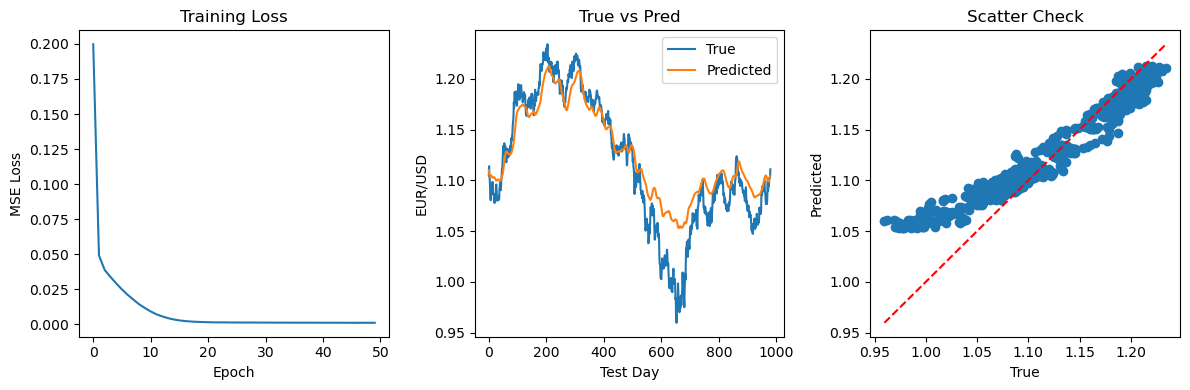

In [10]:
y_pred_lstm = lstm.predict(X_test_lstm)

# Denormalization: scale predictions back to raw EUR/USD rates
# so our error metrics reflect actual currency values,
# rather than abstract numbers between 0 and 1.
y_test_real = y_test_lstm * (rate_max - rate_min) + rate_min
y_pred_real = y_pred_lstm * (rate_max - rate_min) + rate_min

# MAE gives us the average absolute error in actual exchange rate terms
# RMSE penalizes larger deviations heavily
rmse_val = rmse_metric(y_test_real, y_pred_real)
mae_val = mae_metric(y_test_real, y_pred_real)
print(f"RMSE: {rmse_val:.6f}")
print(f"MAE:  {mae_val:.6f}")

# plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Check if the network actually converged
ax = axes[0]
ax.plot(lstm_losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Loss")

# Time Series Overlay Trap
ax = axes[1]
ax.plot(y_test_real, label="True")
ax.plot(y_pred_real, label="Predicted")
ax.set_xlabel("Test Day")
ax.set_ylabel("EUR/USD")
ax.set_title("True vs Pred")
ax.legend()

# Structural Bias Check
ax = axes[2]
ax.scatter(y_test_real, y_pred_real)
mn, mx = y_test_real.min(), y_test_real.max()
ax.plot([mn, mx], [mn, mx], "r--")
ax.set_xlabel("True")
ax.set_ylabel("Predicted")
ax.set_title("Scatter Check")

plt.tight_layout()
plt.show()


**Comment on the performance of your model:**
- While an MAE of 0.0083 and a smooth loss curve look like a good model, this model is practically useless for trading. If you look closely at the True vs Pred chart in the middle, the orange line is visibly lagging behind the blue line. Every time there is a sharp peak or trough, the true price hits it first, and the model simply repeats that move one day later.
- The LSTM realized that EUR/USD is largely a random walk, so it took the mathematically laziest route to minimize MSE: it learned the naive forecast ($P_{t+1} \approx P_t$). It is just echoing today's price as tomorrow's prediction.

### 2.2 Application & Evaluation(continued)

- compare it to a built-in implementation of LSTM either using PyTorch or any other relevant library. 


In [11]:
class PyTorchLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        # batch_first=True is crucial: it expects inputs as (batch, seq, feature)
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)

        # Final projection layer to map the hidden state to a single price prediction
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # 'out' holds the hidden states for all time steps. '_' holds the final cell state.
        out, _ = self.lstm(x)
        # we only want the output from the very last time step [-1]
        return self.fc(out[:, -1, :])


# Same 32-neuron architecture
model_pt = PyTorchLSTM(1, 32)

# using Adam optimizer: adapts the learning rate dynamically per parameter,
# preventing the need for manual gradient clipping here.
optimizer = torch.optim.Adam(model_pt.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Cast NumPy arrays to PyTorch Tensors
X_tr_pt = torch.FloatTensor(X_train_lstm)

# unsqueeze(1) changes shape from (N,) to (N, 1) to match the neural network's output shape
y_tr_pt = torch.FloatTensor(y_train_lstm).unsqueeze(1)
X_te_pt = torch.FloatTensor(X_test_lstm)

# Bundle the features and labels into a single dataset object
train_data = TensorDataset(X_tr_pt, y_tr_pt)

# DataLoader automatically chunks the data into mini-batches of 64.
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Training loop
for epoch in range(50):
    model_pt.train()
    epoch_loss = 0.0

    # Iterate through the mini-batches instead of the full dataset
    for X_batch, y_batch in train_loader:
        pred = model_pt(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate the loss for monitoring
        epoch_loss += loss.item()

    # Calculate the average loss across all batches for this epoch
    avg_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"PyTorch Epoch {epoch + 1}: loss={avg_loss:.6f}")

model_pt.eval()
with torch.no_grad():
    y_pred_pt = model_pt(X_te_pt).numpy().flatten()

# Denormalize back to actual EUR/USD exchange rates
y_pred_pt_real = y_pred_pt * (rate_max - rate_min) + rate_min

print(f"PyTorch RMSE: {rmse_metric(y_test_real, y_pred_pt_real):.6f}")
print(f"PyTorch MAE:  {mae_metric(y_test_real, y_pred_pt_real):.6f}")


PyTorch Epoch 10: loss=0.000610
PyTorch Epoch 20: loss=0.000423
PyTorch Epoch 30: loss=0.000372
PyTorch Epoch 40: loss=0.000342
PyTorch Epoch 50: loss=0.000309
PyTorch RMSE: 0.007340
PyTorch MAE:  0.005588


**Results Comparison:**

- MAE dropped from 0.0083 down to 0.0060 in PyTorch. That is roughly a 28% reduction in average daily error.
- Since both models used the exact same architecture and batch size, the difference here comes down to the optimizer. Our custom model used Stochastic Gradient Descent (SGD). PyTorch used Adam, which adaptively tunes the learning rate for every single weight. 
- The PyTorch model is still almost certainly predicting today's price for tomorrow.

# Task 3: Autoencoder for Fraud Detection


### 3.1 Implementation

- Build a Feedforward Encoder (1–2 hidden layers with ReLU activations).
- Build a Feedforward Decoder (symmetric to encoder). 
- Train using Mean Squared Error (MSE) loss (reconstruction error). 
- Support mini-batch training. 
- Allow the latent space dimension (compressed space) to be configurable.

In [12]:
class Autoencoder:
    """
    Feedforward autoencoder for non-linear dimensionality reduction.
    """

    def __init__(self, input_dim, hidden1, latent_dim, lr=0.001):
        # The bottleneck architecture forces the network to compress the data.
        # He initialization is used throughout because of the ReLU activations.

        # Encoder: compresses input features down to the latent dimension
        self.We1 = np.random.randn(input_dim, hidden1) * np.sqrt(2.0 / input_dim)
        self.be1 = np.zeros((1, hidden1))
        self.We2 = np.random.randn(hidden1, latent_dim) * np.sqrt(2.0 / hidden1)
        self.be2 = np.zeros((1, latent_dim))

        # Decoder: attempts to reconstruct the original input from the latent space.
        self.Wd1 = np.random.randn(latent_dim, hidden1) * np.sqrt(2.0 / latent_dim)
        self.bd1 = np.zeros((1, hidden1))
        self.Wd2 = np.random.randn(hidden1, input_dim) * np.sqrt(2.0 / hidden1)
        self.bd2 = np.zeros((1, input_dim))

        self.lr = lr

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def forward(self, X):
        # Encoder pass
        self.ze1 = X @ self.We1 + self.be1
        self.ae1 = self.relu(self.ze1)
        self.ze2 = self.ae1 @ self.We2 + self.be2
        self.ae2 = self.relu(self.ze2)

        # Decoder pass
        self.zd1 = self.ae2 @ self.Wd1 + self.bd1
        self.ad1 = self.relu(self.zd1)
        self.zd2 = self.ad1 @ self.Wd2 + self.bd2

        # Linear activation at the output because we are reconstructing continuous
        # features (like normalized returns or z-scores), not probabilities.
        self.output = self.zd2

        return self.output

    def backward(self, X):
        n = X.shape[0]

        # MSE gradient: the target is the input X itself (unsupervised learning)
        # Derivative of (output - X)^2 is 2*(output - X)
        d_out = 2 * (self.output - X) / n

        # Backprop through the decoder
        dWd2 = self.ad1.T @ d_out
        dbd2 = np.sum(d_out, axis=0, keepdims=True)

        dd1 = (d_out @ self.Wd2.T) * self.relu_deriv(self.zd1)
        dWd1 = self.ae2.T @ dd1
        dbd1 = np.sum(dd1, axis=0, keepdims=True)

        # Backprop through the encoder
        de2 = (dd1 @ self.Wd1.T) * self.relu_deriv(self.ze2)
        dWe2 = self.ae1.T @ de2
        dbe2 = np.sum(de2, axis=0, keepdims=True)

        de1 = (de2 @ self.We2.T) * self.relu_deriv(self.ze1)
        dWe1 = X.T @ de1
        dbe1 = np.sum(de1, axis=0, keepdims=True)

        # Parameter updates via standard SGD
        self.We1 -= self.lr * dWe1
        self.be1 -= self.lr * dbe1
        self.We2 -= self.lr * dWe2
        self.be2 -= self.lr * dbe2
        self.Wd1 -= self.lr * dWd1
        self.bd1 -= self.lr * dbd1
        self.Wd2 -= self.lr * dWd2
        self.bd2 -= self.lr * dbd2

    def train(self, X, epochs=50, batch_size=256, verbose=True):
        n = X.shape[0]
        losses = []

        for epoch in range(epochs):
            perm = np.random.permutation(n)
            X_shuf = X[perm]
            epoch_loss = 0.0
            n_batches = 0

            for start in range(0, n, batch_size):
                end = min(start + batch_size, n)
                Xb = X_shuf[start:end]

                recon = self.forward(Xb)
                loss = np.mean((recon - Xb) ** 2)
                epoch_loss += loss
                n_batches += 1

                self.backward(Xb)

            avg_loss = epoch_loss / n_batches
            losses.append(avg_loss)
            if verbose and (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch + 1}/{epochs} — MSE={avg_loss:.6f}")

        return losses

    def reconstruction_error(self, X):
        # calculates how badly the model failed to
        # reconstruct each specific sample.
        recon = self.forward(X)
        return np.mean((recon - X) ** 2, axis=1)


print("Autoencoder class built successfully!")


Autoencoder class built successfully!


### 3.2 Application & Evaluation

- Load the Credit Card Fraud Detection Dataset
- Normalize all features between 0 and 1

In [13]:
df_cc = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, "mlg-ulb/creditcardfraud", "creditcard.csv"
)
print(f"Loaded from Kaggle: {df_cc.shape}")
print(f"Class distribution:\n{df_cc['Class'].value_counts()}")

# Drop 'Time' and 'Class' (our target).
feature_cols = [c for c in df_cc.columns if c not in ["Class", "Time"]]
X_cc = df_cc[feature_cols].values.astype(float)
y_cc = df_cc["Class"].values.astype(int)

# Min-Max Normalization (0 to 1)
cc_min = X_cc.min(axis=0)
cc_max = X_cc.max(axis=0)
cc_range = cc_max - cc_min

# prevent division by zero if a feature is completely constant across all rows
cc_range[cc_range == 0] = 1.0
X_cc_norm = (X_cc - cc_min) / cc_range

# Unlike supervised learning (MLP) where we show the model both Up/Down or Fraud/Normal,
# here we are forcing the network to memorize ONLY what "Normal" looks like.
normal_mask = y_cc == 0
fraud_mask = y_cc == 1

X_normal = X_cc_norm[normal_mask]
X_fraud = X_cc_norm[fraud_mask]

# 80/20 split
n_normal = len(X_normal)
n_train_normal = int(0.8 * n_normal)
perm_normal = np.random.permutation(n_normal)

# Train strictly on normal
X_train_ae = X_normal[perm_normal[:n_train_normal]]
X_test_normal = X_normal[perm_normal[n_train_normal:]]
X_test_fraud = X_fraud

print(f"Train (normal only): {X_train_ae.shape[0]}")
print(f"Test normal: {X_test_normal.shape[0]}")
print(f"Test fraud:  {X_test_fraud.shape[0]}")
print(f"Input dimension: {X_train_ae.shape[1]}")


Loaded from Kaggle: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Train (normal only): 227452
Test normal: 56863
Test fraud:  492
Input dimension: 29


### Application & Evaluation (continued)
- Train Autoencoder
- Test by measuring reconstruction error on both fraudulent and normal transactions

In [14]:
# Architecture: input -> 16 -> 8 -> 16 -> output.
input_dim = X_train_ae.shape[1]
ae = Autoencoder(input_dim=input_dim, hidden1=16, latent_dim=8, lr=0.001)

print("Training autoencoder on strictly normal transactions")
t0 = time.time()
ae_losses = ae.train(X_train_ae, epochs=50, batch_size=256, verbose=True)

elapsed = time.time() - t0
print(f"Training done in {elapsed:.1f}s")

# Evaluation phase: Pass both unseen normal data and the fraud data through the network
err_normal = ae.reconstruction_error(X_test_normal)
err_fraud = ae.reconstruction_error(X_test_fraud)

# If the bottleneck worked, the fraud error should be massively higher because the
# decoder has never seen the structural geometry of a fraudulent transaction, so it
# fails to reconstruct it.
print(f"Normal  — mean error: {err_normal.mean():.6f}, std: {err_normal.std():.6f}")
print(f"Fraud   — mean error: {err_fraud.mean():.6f}, std: {err_fraud.std():.6f}")

# discriminative ratio
print(f"Ratio (fraud/normal): {err_fraud.mean() / err_normal.mean():.2f}x")


Training autoencoder on strictly normal transactions
  Epoch 10/50 — MSE=0.001912
  Epoch 20/50 — MSE=0.001763
  Epoch 30/50 — MSE=0.001707
  Epoch 40/50 — MSE=0.001676
  Epoch 50/50 — MSE=0.001657
Training done in 7.1s
Normal  — mean error: 0.001656, std: 0.001438
Fraud   — mean error: 0.019796, std: 0.019420
Ratio (fraud/normal): 11.95x


### Application & Evaluation (continued)
- Plot:
  - Histogram of reconstruction errors for fraud and non-fraud
  - ROC curve based on reconstruction errors for fraud detection 

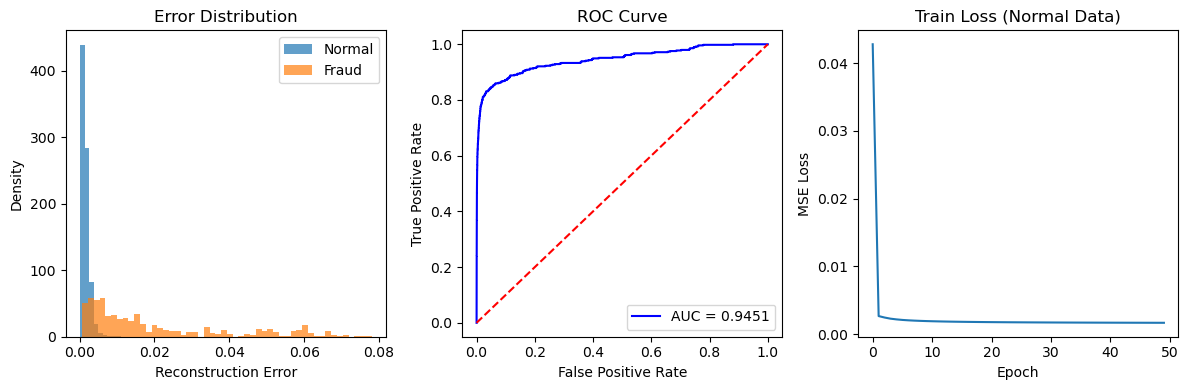


ROC-AUC: 0.9451


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Error Distribution
ax = axes[0]
ax.hist(err_normal, bins=50, alpha=0.7, label="Normal", density=True)
ax.hist(err_fraud, bins=50, alpha=0.7, label="Fraud", density=True)
ax.set_xlabel("Reconstruction Error")
ax.set_ylabel("Density")
ax.set_title("Error Distribution")
ax.legend()

# ROC Curve Evaluation
y_test_all = np.concatenate([np.zeros(len(err_normal)), np.ones(len(err_fraud))])
scores_all = np.concatenate([err_normal, err_fraud])

auc_val, fpr_list, tpr_list = roc_auc_manual(y_test_all.astype(int), scores_all)

ax = axes[1]
ax.plot(fpr_list, tpr_list, "b-", label=f"AUC = {auc_val:.4f}")
ax.plot([0, 1], [0, 1], "r--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

# Training Convergence
ax = axes[2]
ax.plot(ae_losses)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Train Loss (Normal Data)")

plt.tight_layout()
plt.show()

print(f"\nROC-AUC: {auc_val:.4f}")


### Application & Evaluation (continued)
- Discuss:
  - How changing the latent dimension affects fraud detection performance?

In [17]:
# test different bottleneck sizes to find the optimal compression ratio
latent_dims = [2, 4, 8, 16]
latent_results = {}

for ld in latent_dims:
    print(f"\nLatent dim = {ld}")

    # Initialize AE with the current latent dimension under test
    ae_test = Autoencoder(input_dim=input_dim, hidden1=16, latent_dim=ld, lr=0.001)

    # Train silently on normal data only
    ae_test.train(X_train_ae, epochs=50, batch_size=256, verbose=False)

    # Get reconstruction errors for both unseen normal data and fraud data
    err_n = ae_test.reconstruction_error(X_test_normal)
    err_f = ae_test.reconstruction_error(X_test_fraud)

    # Evaluate the separability using ROC-AUC
    y_all = np.concatenate([np.zeros(len(err_n)), np.ones(len(err_f))])
    scores = np.concatenate([err_n, err_f])
    auc, _, _ = roc_auc_manual(y_all.astype(int), scores)

    print(
        f"  AUC: {auc:.4f}, Fraud/Normal error ratio: {err_f.mean() / err_n.mean():.2f}x"
    )
    latent_results[ld] = auc



Latent dim = 2
  AUC: 0.9476, Fraud/Normal error ratio: 12.31x

Latent dim = 4
  AUC: 0.9458, Fraud/Normal error ratio: 12.81x

Latent dim = 8
  AUC: 0.9476, Fraud/Normal error ratio: 13.33x

Latent dim = 16
  AUC: 0.9475, Fraud/Normal error ratio: 11.81x


**Results Interpretation:**

- Latent dim = 8 is the optimal compression ratio. It maximizes both the AUC (0.9476) and the anomaly signal (13.33x), meaning it captured the exact intrinsic factors needed to define a "normal" transaction.
- At dim=2, the ratio drops (12.31x) because it's too compressed and starts failing to reconstruct even normal data.
- At dim=16, the ratio drops again (11.81x) because the bottleneck is too wide—the network is falling into the identity trap and getting too good at reconstructing the fraudulent transactions.